# Nanopore Metagenomic Sequencing Analysis Report
**Sample:** 1_024_O  
**Date:** 25 of April 2026  
**Pipeline:** NanoStat → Filtlong → Kraken2 → Flye → seqkit → Kraken2 → BLAST → Prodigal → CheckV

## 1. Introduction

This report describes the quality control, assembly, and characterization of a Nanopore long-read sequencing dataset (sample 1_024_O). The sample origin and target organism were not specified a priori; the analysis was therefore approached in an exploratory manner, with organism identity inferred from the data itself.

Initial taxonomic classification of raw reads using Kraken2 revealed a highly diverse community with no single dominant organism, indicating a metagenomic sample. Accordingly, all downstream steps were performed using metagenome-appropriate modes and tools.

The full pipeline was implemented in **Snakemake** to ensure reproducibility and scalability to HPC environments.

## 2. Methods

### 2.1 Environment
Two conda environments were used:
- `veo_env` (Python 3.10): NanoStat, NanoPlot, Filtlong, Kraken2, Flye, seqkit, Prodigal
- `checkv`: CheckV v1.0

### 2.2 Raw Read QC
Read quality and length statistics were assessed using **NanoStat**, and visualized using **NanoPlot**.

### 2.3 Read Filtering
Reads shorter than 1,000 bp were removed using **Filtlong** (`--min_length 1000`). Quality-based filtering was not applied, as 100% of reads passed Q10 and the dataset was too small to afford coverage loss.

### 2.4 Taxonomic Classification of Reads
Raw reads were classified using **Kraken2** against the k2_standard_08gb database (October 2023) to assess community composition and inform assembly strategy.

### 2.5 Genome Assembly
Metagenome assembly was performed using **Flye** v2.9 with `--nano-raw --meta` flags. The `--nano-raw` mode was chosen based on median read quality of Q14 (below the Q20 threshold required for `--nano-hq`). The `--meta` flag enables assembly of heterogeneous communities with uneven coverage.

### 2.6 Assembly QC
Assembly statistics (contig count, total length, N50, GC%) were computed using **seqkit stats** (`-a` flag).

### 2.7 Contig Characterization
Assembled contigs were characterized using a multi-tool approach:
- **Kraken2** (per-sequence output) for initial taxonomic assignment
- **NCBI BLASTn** (online, database: nt) for the unclassified contig
- **Prodigal** (`-p meta`) for gene prediction
- **CheckV** for viral genome completeness and contamination assessment

### 2.8 Pipeline
All steps were integrated into a **Snakemake** pipeline with per-rule conda environments, enabling reproducible execution from raw reads to final results with a single command.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Plot styling
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## 3. Results

### 3.1 Raw Read QC

In [11]:
# NanoStat summary table
nanostat = pd.DataFrame({
    'Metric': [
        'Number of reads',
        'Total bases (Mb)',
        'Mean read length (bp)',
        'Median read length (bp)',
        'Read length N50 (bp)',
        'Max read length (bp)',
        'Mean read quality (Q)',
        'Median read quality (Q)',
        'Reads > Q10 (%)',
        'Reads > Q15 (%)',
        'Reads > Q20 (%)'
    ],
    'Value': [
        '5,251',
        '50.8',
        '9,677',
        '6,962',
        '14,392',
        '255,199',
        '13.6',
        '14.1',
        '100.0',
        '25.2',
        '0.1'
    ]
})

nanostat.style.set_caption('Table 1. Raw read QC statistics (NanoStat)') \
              .hide(axis='index') \
              .set_properties(**{'text-align': 'left'})

Metric,Value
Number of reads,"5,251"
Total bases (Mb),50.8
Mean read length (bp),"9,677"
Median read length (bp),"6,962"
Read length N50 (bp),"14,392"
Max read length (bp),"255,199"
Mean read quality (Q),13.6
Median read quality (Q),14.1
Reads > Q10 (%),100.0
Reads > Q15 (%),25.2


The dataset consists of 5,251 reads totalling 50.8 Mb with a median read quality of Q14.1. All reads pass the Q10 threshold, while only 0.1% reach Q20, consistent with standard Nanopore R9.4.1 chemistry with conventional basecalling. Read lengths are well-suited for long-read assembly, with a median of 6.9 kb, N50 of 14.4 kb, and ultra-long reads up to 255 kb.

### 3.2 Taxonomic Classification of Raw Reads

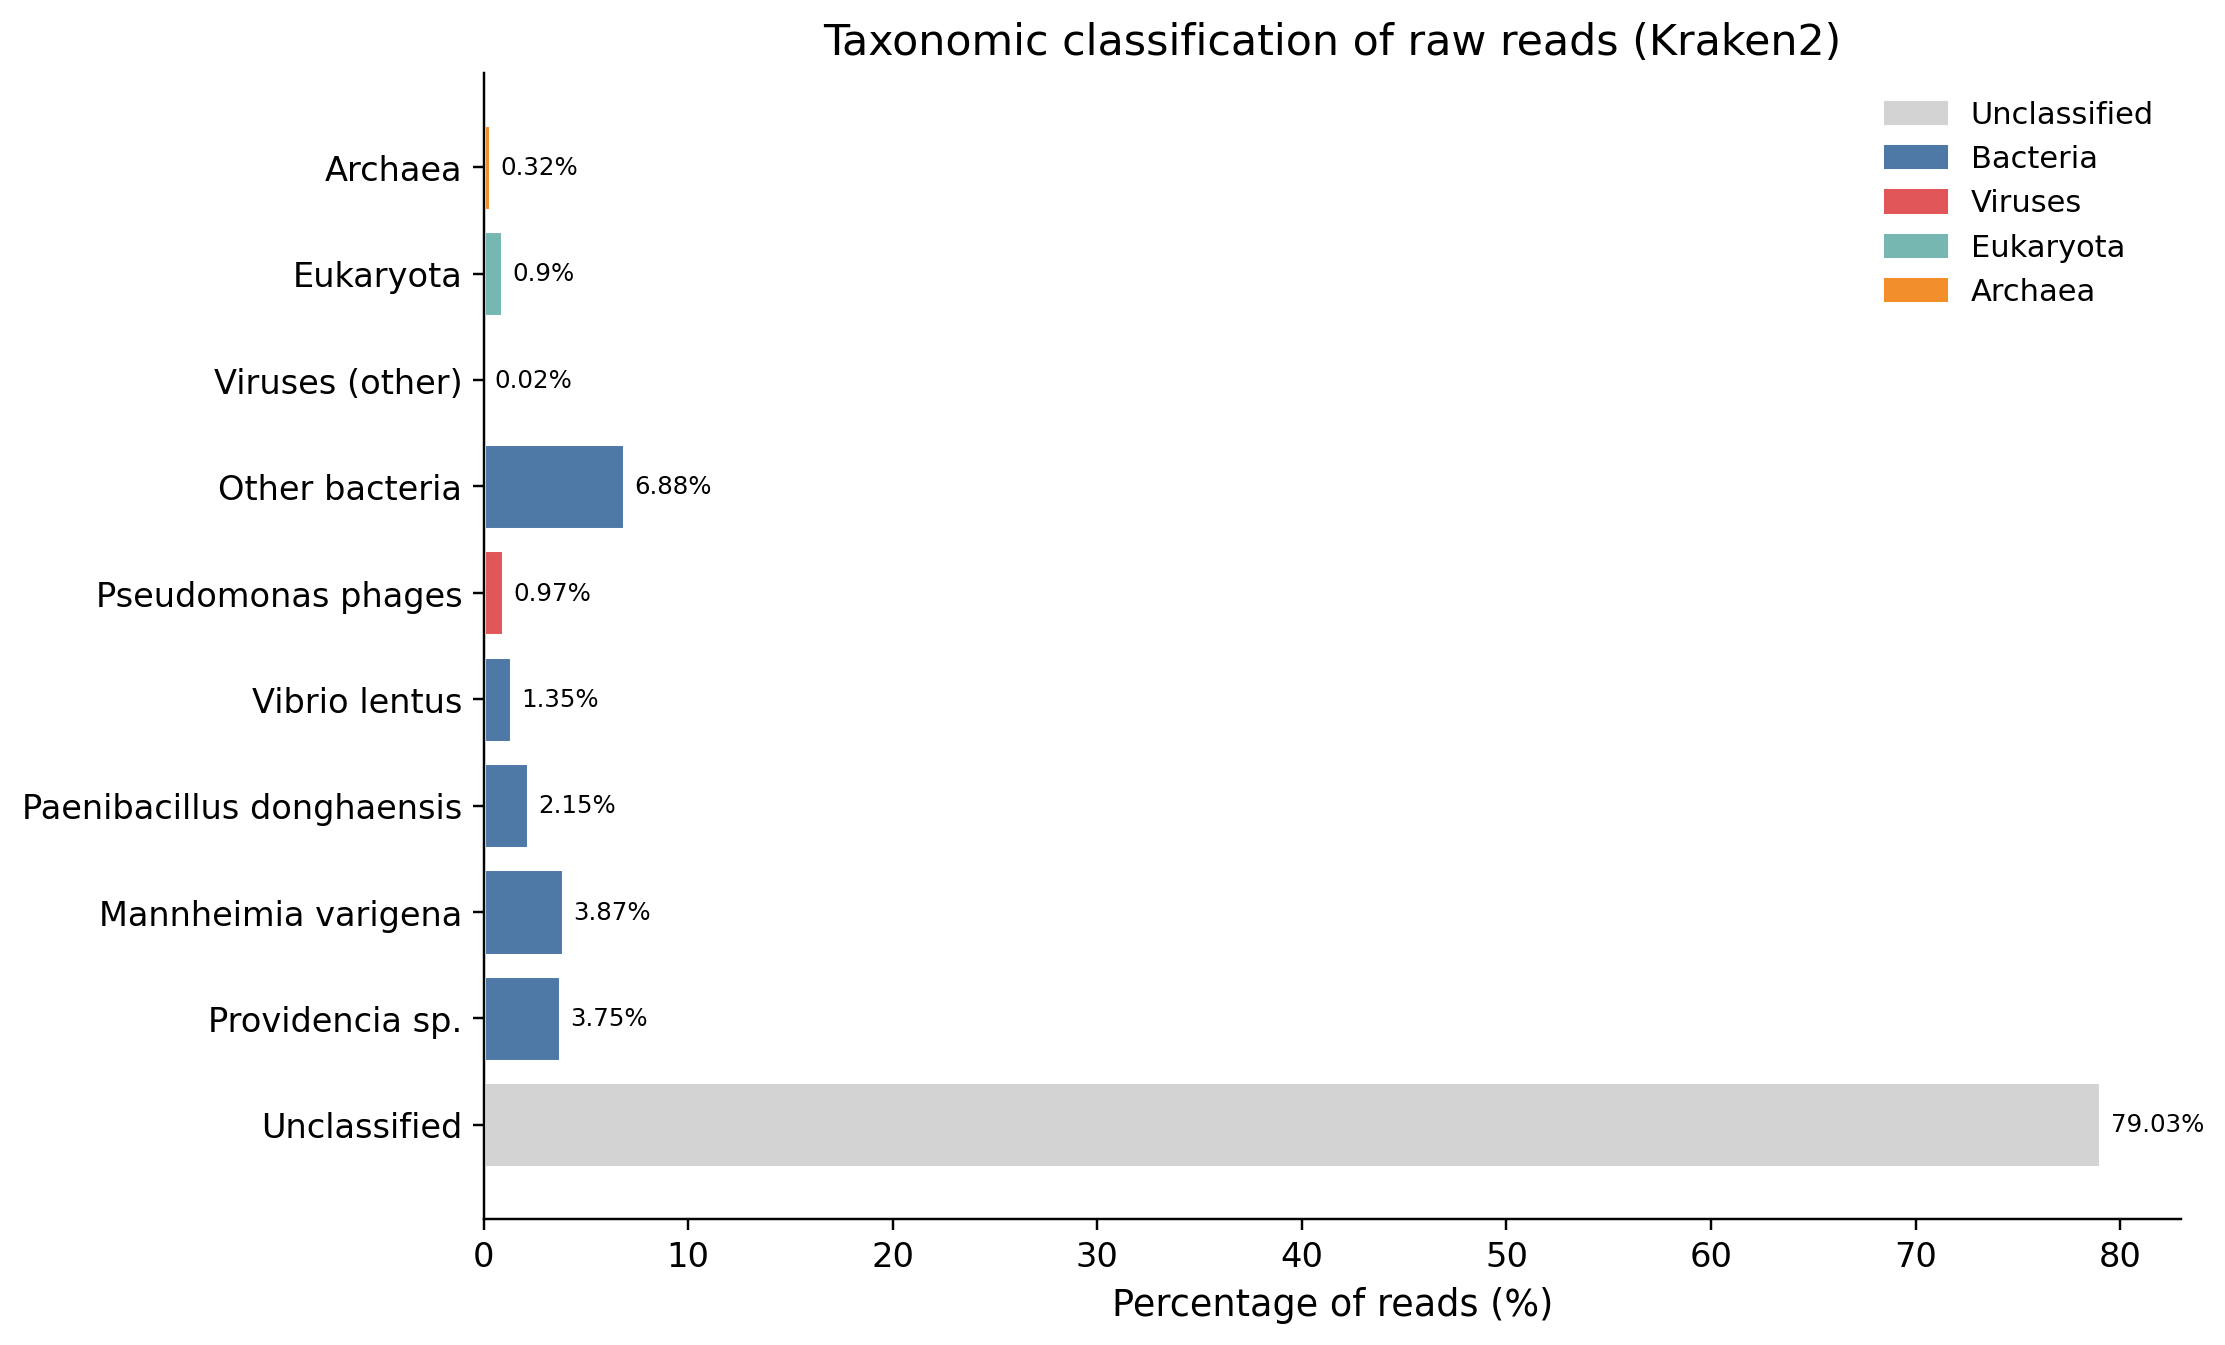

In [ ]:
# Kraken2 reads - top hits visualisation
labels = [
    'Unclassified',
    'Providencia sp.',
    'Mannheimia varigena',
    'Paenibacillus donghaensis',
    'Vibrio lentus',
    'Pseudomonas phages',
    'Other bacteria',
    'Viruses (other)',
    'Eukaryota',
    'Archaea'
]
values = [79.03, 3.75, 3.87, 2.15, 1.35, 0.97, 6.88, 0.02, 0.90, 0.32]
colors = ['#d3d3d3', '#4e79a7', '#4e79a7', '#4e79a7', '#4e79a7',
          '#e15759', '#4e79a7', '#e15759', '#76b7b2', '#f28e2b']

fig, ax = plt.subplots(figsize=(10, 6), dpi=220)
bars = ax.barh(labels, values, color=colors, edgecolor='white')
ax.set_title("Figure 1. Taxonomic classification of raw reads (Kraken2)", fontsize=14)
ax.tick_params(axis='both', labelsize=11)
ax.set_xlabel("Percentage of reads (%)", fontsize=12)

ax.axvline(x=0, color='black', linewidth=0.5)

for bar, val in zip(bars, values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=8)

patches = [
    mpatches.Patch(color='#d3d3d3', label='Unclassified'),
    mpatches.Patch(color='#4e79a7', label='Bacteria'),
    mpatches.Patch(color='#e15759', label='Viruses'),
    mpatches.Patch(color='#76b7b2', label='Eukaryota'),
    mpatches.Patch(color='#f28e2b', label='Archaea'),
]
ax.legend(handles=patches, fontsize=10, frameon=False)

plt.tight_layout(pad=0.3)
plt.savefig("results/figures/kraken_reads.png", dpi=300, bbox_inches="tight", pad_inches=0.02)
plt.show()

79% of reads remained unclassified against the k2_standard_08gb database, suggesting the presence of organisms poorly represented in current databases — consistent with environmental viral sequences. Among classified reads, the dominant taxa were *Providencia* sp. (3.75%), *Mannheimia varigena* (3.87%), and *Paenibacillus donghaensis* (2.15%). Pseudomonas phages (Autographiviridae) accounted for ~1% of classified reads.

The absence of a single dominant organism and high unclassified fraction indicated a **metagenomic sample**, and accordingly Flye was run in `--meta` mode.

### 3.3 Assembly QC

In [6]:
# Assembly statistics table
assembly_stats = pd.DataFrame({
    'Metric': [
        'Number of contigs',
        'Total length (bp)',
        'Largest contig (bp)',
        'Smallest contig (bp)',
        'N50 (bp)',
        'GC content (%)'
    ],
    'Value': [
        '5',
        '183,086',
        '58,829',
        '11,397',
        '41,137',
        '49.84'
    ]
})

assembly_stats.style.set_caption('Table 2. Assembly statistics (seqkit stats)') \
                    .hide(axis='index')

Metric,Value
Number of contigs,5
Total length (bp),"183,086"
Largest contig (bp),"58,829"
Smallest contig (bp),"11,397"
N50 (bp),"41,137"
GC content (%),49.84


Flye assembled 5 contigs totalling 183 kb: approximately 0.4% of the 50.8 Mb input. This low recovery is expected in metagenomic assemblies with low per-organism coverage: when sequencing depth is distributed across many organisms, most fall below the minimum coverage threshold required for assembly (~10×). Only organisms with sufficient local coverage were assembled. The assembled contigs are all >11 kb, with a strong N50 of 41 kb, indicating good contiguity for the fraction that was assembled.

### 3.4 Contig Characterization

#### 3.4.1 Kraken2 per-contig classification 

In [7]:
# Full characterization table
contigs = pd.DataFrame({
    'Contig': ['contig_1', 'contig_2', 'contig_3', 'contig_4', 'contig_5'],
    'Length (bp)': ['39,266', '11,397', '41,137', '32,457', '58,829'],
    'Kraken2 assignment': [
        'Vibrio sp. J383',
        'Pseudomonas phage Bf7',
        'Pseudomonas phage 17A',
        'Unclassified → Vibrio phage (BLAST)',
        'Providencia sp. PROV188'
    ],
    'Total genes': [66, 24, 94, 65, 84],
    'Viral genes': [23, 11, 41, 25, 37],
    'Host genes': [0, 0, 0, 0, 0],
    'CheckV quality': [
        'High-quality',
        'Low-quality',
        'High-quality',
        'Medium-quality',
        'High-quality'
    ],
    'Completeness (%)': [100.0, 23.1, 94.1, 79.5, 97.0]
})

def highlight_quality(val):
    if val == 'High-quality':
        return 'background-color: #c8e6c9'
    elif val == 'Medium-quality':
        return 'background-color: #fff9c4'
    elif val == 'Low-quality':
        return 'background-color: #ffcdd2'
    return ''

contigs.style.set_caption('Table 3. Contig characterization summary') \
             .hide(axis='index') \
             .applymap(highlight_quality, subset=['CheckV quality'])

/var/folders/9g/sdd1qhg95pg90bkpxpf3_6c40000gn/T/ipykernel_2935/161360454.py:34: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  contigs.style.set_caption('Table 3. Contig characterization summary') \


Contig,Length (bp),Kraken2 assignment,Total genes,Viral genes,Host genes,CheckV quality,Completeness (%)
contig_1,"39,266",Vibrio sp. J383,66,23,0,High-quality,100.000000
contig_2,"11,397",Pseudomonas phage Bf7,24,11,0,Low-quality,23.100000
contig_3,"41,137",Pseudomonas phage 17A,94,41,0,High-quality,94.100000
contig_4,"32,457",Unclassified → Vibrio phage (BLAST),65,25,0,Medium-quality,79.500000
contig_5,"58,829",Providencia sp. PROV188,84,37,0,High-quality,97.000000


#### 3.4.2 BLAST characterization of unclassified contig_4

In [ ]:
blast_results = pd.DataFrame({
    'Rank': [1, 2, 3, 4, 5],
    'Subject': [
        'Vibrio phage 1.134.O._10N.222.52.B8',
        'Vibrio phage 1.172.O._10N.261.52.F5',
        'Vibrio phage 1.116.O._10N.222.52.C10',
        'Vibrio phage 1.085.O._10N.222.51.E3',
        'Vibrio phage 1.176.O._10N.261.55.F5'
    ],
    'Accession': [
        'MG592505.1', 'MG592539.1', 'MG592490.1', 
        'MG592460.1', 'MG592543.1'
    ],
    'Query cover (%)': [71, 88, 88, 89, 72],
    'Identity (%)': [98.48, 97.95, 97.95, 97.79, 94.67],
    'E-value': ['0.0', '0.0', '0.0', '0.0', '0.0']
})

blast_results.style.set_caption(
    'Table 4. Top BLASTn hits for contig_4 (NCBI nt database)') \
    .hide(axis='index') \
    .bar(subset=['Identity (%)'], color='#c8e6c9', vmin=90, vmax=100) \
    .bar(subset=['Query cover (%)'], color='#bbdefb', vmin=0, vmax=100)

Rank,Subject,Accession,Query cover (%),Identity (%),E-value
1,Vibrio phage 1.134.O._10N.222.52.B8,MG592505.1,71,98.480000,0.0
2,Vibrio phage 1.172.O._10N.261.52.F5,MG592539.1,88,97.950000,0.0
3,Vibrio phage 1.116.O._10N.222.52.C10,MG592490.1,88,97.950000,0.0
4,Vibrio phage 1.085.O._10N.222.51.E3,MG592460.1,89,97.790000,0.0
5,Vibrio phage 1.176.O._10N.261.55.F5,MG592543.1,72,94.670000,0.0


Blastn taxonomic tree with **contig_4**: 
https://www.ncbi.nlm.nih.gov/blast/treeview/treeView.cgi?request=page&blastRID=YKUV08RX016&queryID=lcl|Query_4838905&entrezLim=&ex=&exl=&exh=&ns=100&screenWidth=1512&screenHeight=982

Contig_4 remained unclassified by Kraken2, with only 5 k-mer hits against 
the entire database. BLASTn against NCBI nt (database: nt, April 2026) 
returned 46 significant alignments, all to **Vibrio phages** of the same 
environmental phage collection (E-value = 0.0 in all cases).

The top hit -- *Vibrio phage 1.134.O._10N.222.52.B8* (MG592505.1) -- showed 
98.48% nucleotide identity over 71% query coverage, confirming contig_4 as 
a near-complete Vibrio phage genome absent from the Kraken2 database. 

The NCBI distance tree placed contig_4 within a well-supported clade of 
environmental Vibrio phages, with *Vibrio phage 1.085.O._10N.222.51.E3* 
as the closest neighbour consistent with CheckV's Medium-quality 
assessment at 79.5% completeness.

### 3.4.3 Viral genome completeness (CheckV)

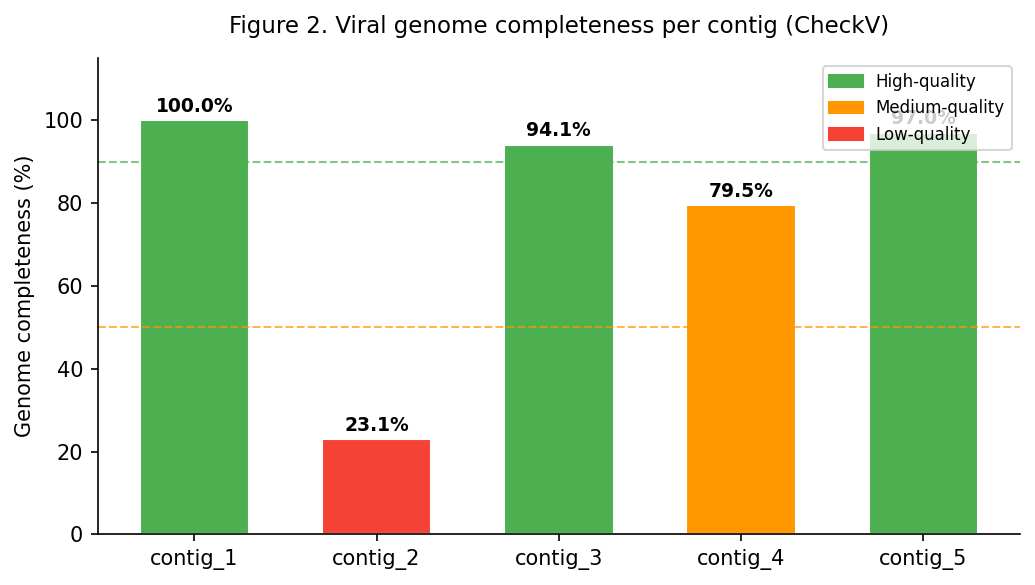

In [8]:
# Completeness bar chart
fig, ax = plt.subplots(figsize=(7, 4))

contig_names = ['contig_1', 'contig_2', 'contig_3', 'contig_4', 'contig_5']
completeness = [100.0, 23.1, 94.1, 79.5, 97.0]
quality_colors = ['#4caf50', '#f44336', '#4caf50', '#ff9800', '#4caf50']

bars = ax.bar(contig_names, completeness, color=quality_colors, 
              edgecolor='white', width=0.6)

ax.axhline(y=90, color='#4caf50', linestyle='--', linewidth=1, 
           alpha=0.7, label='High-quality threshold (90%)')
ax.axhline(y=50, color='#ff9800', linestyle='--', linewidth=1, 
           alpha=0.7, label='Medium-quality threshold (50%)')

for bar, val in zip(bars, completeness):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Genome completeness (%)')
ax.set_ylim(0, 115)
ax.set_title('Figure 2. Viral genome completeness per contig (CheckV)', 
             fontsize=11, pad=12)
ax.legend(fontsize=8)

patches = [
    mpatches.Patch(color='#4caf50', label='High-quality'),
    mpatches.Patch(color='#ff9800', label='Medium-quality'),
    mpatches.Patch(color='#f44336', label='Low-quality'),
]
ax.legend(handles=patches, loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig('results/figures/checkv_completeness.png', bbox_inches='tight')
plt.show()

### 3.4.4 Gene prediction (Prodigal)

Gene prediction was performed using Prodigal in metagenome mode (`-p meta`).
A total of **333 genes** were predicted across 5 contigs, with the following
distribution:

| Contig | Predicted genes |
|---|---|
| contig_1 | 66 |
| contig_2 | 24 |
| contig_3 | 94 |
| contig_4 | 65 |
| contig_5 | 84 |

The low gene count for contig_2 (24 genes) is consistent with its low 
completeness (23.1%), representing only a fragment of the full phage genome.
Predicted protein sequences were exported in FASTA format for potential 
downstream functional annotation.

**Kraken2 per-contig classification** assigned four contigs to known taxa and left contig_4 unclassified (only 5 k-mer hits in the database). BLASTn against NCBI nt identified contig_4 as a **Vibrio phage** with up to 98.48% nucleotide identity to *Vibrio phage 1.134.O._10N.222.52.B8*, placing it within a well-supported phage clade in the distance tree.

**CheckV** revealed that all five contigs have exclusively viral gene content (host_genes = 0 in all cases), with viral gene fractions ranging from 35–44% of total predicted genes — the remainder being genes of unknown function, typical for phage genomes. Notably, **contig_1** and **contig_5** were assigned to bacterial taxa by Kraken2 (*Vibrio* sp. and *Providencia* sp., respectively), yet CheckV classified both as high-quality viral genomes with >96% completeness. This discordance likely reflects sequence similarity between phage genomes and their bacterial hosts in k-mer space.

**Prodigal** predicted a total of 333 genes across 5 contigs (mean: 66.6 genes/contig).

## 4. Discussion

### The sample is a viral metagenome

Despite initial Kraken2 signals suggesting bacterial origins, CheckV analysis unambiguously identified all five assembled contigs as viral genomes, with zero host gene contamination across all contigs. Three contigs reached >94% completeness (High-quality by MIUViG standards). The taxonomic profile — Pseudomonas phages (Autographiviridae), Vibrio phages — is consistent with a **marine or coastal environmental sample**, where these phage groups are commonly found.

### Limitations of k-mer based classification for viral sequences

The high unclassified fraction (79% of reads) and the misclassification of contig_1 and contig_5 by Kraken2 illustrate a well-known limitation: k-mer databases are biased toward well-studied bacterial genomes, and viral sequences are systematically underrepresented. This underscores the importance of using **complementary tools** (Kraken2 + BLAST + CheckV) rather than relying on any single classifier.

### Low assembly yield

Only 183 kb (0.4%) of input data was assembled into contigs. This is a direct consequence of low per-organism coverage in a complex metagenomic sample: with 50.8 Mb distributed across many organisms, most fall below Flye's minimum coverage threshold. Deeper sequencing or targeted enrichment (e.g., virome preparation) would substantially improve assembly completeness.

### contig_2 fragmentation

Contig_2 (*Pseudomonas phage Bf7*) assembled at only 23.1% completeness, the lowest of all contigs. This is consistent with very low coverage of this particular phage in the sample, resulting in a highly fragmented assembly.

## 5. Conclusions

- Sample 1_024_O is a **viral metagenome**, likely of marine/environmental origin, dominated by bacteriophages infecting *Vibrio* and *Pseudomonas* hosts.
- Five contigs were assembled, three of which represent **high-quality, near-complete phage genomes** (completeness >94%).
- Kraken2 alone was insufficient for accurate characterization of viral contigs; combining it with **BLASTn and CheckV** was essential for correct identification.
- The full analysis pipeline was implemented in **Snakemake** with conda environment management, ensuring reproducibility and portability to HPC systems.
- Increased sequencing depth or virome enrichment would be recommended to improve metagenome recovery in future experiments.

## 6. Software versions

| Tool | Version | Purpose |
|---|---|---|
| NanoStat | 1.6.0 | Raw read QC |
| NanoPlot | 1.41.0 | Read QC visualization |
| Filtlong | 0.2.1 | Read filtering |
| Kraken2 | 2.1.3 | Taxonomic classification |
| Flye | 2.9.3 | Metagenome assembly |
| seqkit | 2.7.0 | Assembly QC |
| Prodigal | 2.6.3 | Gene prediction |
| CheckV | 1.0.1 | Viral genome completeness |
| Snakemake | 7.x | Pipeline management |
| NCBI BLASTn | online | Contig identification |